# Part 3: Behavioral Data Analysis: Go/NoGo Task ⌨️

Before we dive into the complex world of brainwaves (EEG), we need to look at the behavioral data.

In a Go/NoGo task, we generate a `.csv` file that logs every single trial. We are mainly interested in two behavioral metrics:
1. **Accuracy:** The percentage of correct responses.
2. **Reaction Time (RT):** How fast the participant pressed the button.

### Setup and Loading Data
You may import `pandas` for data handling and `seaborn`/`matplotlib` for some aesthetic plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Set style for our plots
### NOTE: Remove and let them decide
sns.set_theme(style="whitegrid")


sub_id = 'sub-4'
# Load the behavioral data 
# (Make sure the path matches your .csv file)
CSVFILE_DIR = f'../data/hackathon_data/{sub_id}/beh'

# Load the behavioral data 
# (Make sure the path matches your .csv file)
csv_files = glob.glob(os.path.join(CSVFILE_DIR, '*.csv'))[0] #automatically matches the csv file in your path (we select only the first one, as there only is one anyways)

print(f"Found {os.path.basename(csv_files)}") #safety check
df_raw = pd.read_csv(csv_files)

Found sub-4_gonogo_task.csv


## Clean Data from PsychoPy Issues
PsychoPy writes a separate line in the CSV file for **each routine** (TrialIntro, Delay, Breaks, TrialOutro) – even if there is no trial data there. These lines have no value in the `type` column and must be filtered out.

In [2]:
df = df_raw.dropna(subset=['type']).copy()
df = df[df['type'].isin(['go', 'nogo'])].copy()

print(f"Left: {len(df)}")
print(f"Deleted: {len(df_raw) - len(df)} - lines that contaminate the data (Intro, Delay, Breaks, Outro)\n")


# Look for Number of Go vs. NoGo Trials (should be around 75/25)
print(df['type'].value_counts())
print(f"\nTotal: {len(df)} Trials")

# Check: for how many of the Trials do we have response times?
# the two df columns are identical (due to PsychoPy output format)
print("TrialResp.rt vorhanden:", df['TrialResp.rt'].notna().sum())
print("TrialLoop.TrialResp.rt vorhanden:", df['TrialLoop.TrialResp.rt'].notna().sum())

# Check: how many of the Trials have been answered correctly?
# the two df columns are identical (due to PsychoPy output format)
print("TrialResp.corr vorhanden:", df['TrialResp.corr'].notna().sum())
print("TrialLoop.TrialResp.corr vorhanden:", df['TrialLoop.TrialResp.corr'].notna().sum())

Left: 211
Deleted: 2 - lines that contaminate the data (Intro, Delay, Breaks, Outro)

type
go      158
nogo     53
Name: count, dtype: int64

Total: 211 Trials
TrialResp.rt vorhanden: 158
TrialLoop.TrialResp.rt vorhanden: 158
TrialResp.corr vorhanden: 210
TrialLoop.TrialResp.corr vorhanden: 210


## Task 1: Accuracy (Hits vs. Correct Rejections) 🎯

In our task, the participant had to press the spacebar for certain images (Go) and withhold their response for others (NoGo). 

Our dataset has a column called `TrialResp.corr` which is `1` if the participant did the right thing, and `0` if they made a mistake.

**Your Task:**
1. Group the dataset by condition (Go vs. NoGo). *Hint: You can figure out the condition by looking at the `corrAns` column!*
2. Calculate the mean accuracy (percentage) for both conditions.
3. Plot the results in a simple bar chart.

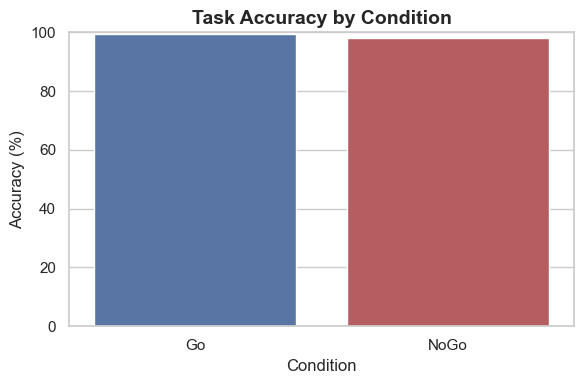

Hit Rate (Correct Go):              99.37%
Correct Rejection Rate (Correct NoGo): 98.11%


In [3]:
# Define Go and NoGo trials based on the 'corrAns' column
# If the correct answer was 'None' or empty, it was a NoGo trial!
df['Condition'] = df['corrAns'].apply(
    lambda x: 'NoGo' if pd.isna(x) else 'Go'
)

# Calculate Accuracy (mean of the 'TrialResp.corr' column * 100)
### NOTE: Remove the groupby and plotting logic for the exercise
df['TrialResp.corr'] = df['TrialResp.corr'].fillna(0.0)  
#important, since NAs will otherwise simply be omitted from the mean calculation, but we want to treat NAs as missed trials

accuracy = df.groupby('Condition')['TrialResp.corr'].mean() * 100

# Plot Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x=accuracy.index, y=accuracy.values, hue=accuracy.index, palette=['#4C72B0', '#C44E52'], legend=False)
plt.title('Task Accuracy by Condition', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Hit Rate (Correct Go):              {accuracy.get('Go', 0):.2f}%")
print(f"Correct Rejection Rate (Correct NoGo): {accuracy.get('NoGo', 0):.2f}%")

## Task 2: Reaction Times ⏱️

Reaction times (RTs) tell us a lot about cognitive control. Often, when participants make a mistake on a NoGo trial (a **False Alarm**), it happens because they are reacting too fast (impusively), failing to inhibit their motor response in time.

**Your Task:**
1. Filter out all trials where no button was pressed (where RT is missing/NaN).
2. Separate the remaining trials into **Hits** (Correct Go responses) and **False Alarms** (Incorrect NoGo responses).
3. Create a violin plot or boxplot to compare the reaction times of Hits vs. False Alarms.

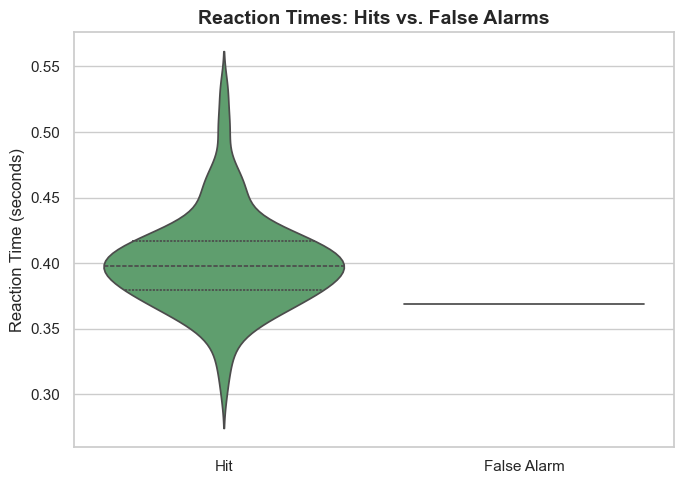

Summary: Reaction Time (in seconds)


,count,mean,std
ResponseType,,,
False Alarm,1.0,0.368799,NaN
Hit,157.0,0.401044,0.036559


In [4]:
# Filter out trials where no response was made (RT is NaN)
df_responded = df.dropna(subset=['TrialResp.rt']).copy()

# 2. Determine Response Type: Hit vs False Alarm
### NOTE: Remove the lambda function and plotting logic for the exercise
df_responded['ResponseType'] = df_responded.apply(
    lambda row: 'Hit' if row['Condition'] == 'Go' and row['TrialResp.corr'] == 1
    else ('False Alarm' if row['Condition'] == 'NoGo' and row['TrialResp.corr'] == 0
          else 'Other'),
    axis=1
)

# Filter to only keep Hits and False Alarms
df_rts = df_responded[df_responded['ResponseType'].isin(['Hit', 'False Alarm'])]

# Plot Reaction Times
plt.figure(figsize=(7, 5))
sns.violinplot(
    data=df_rts, x='ResponseType', y='TrialResp.rt',
    palette=['#55A868', '#C44E52'], inner="quartile",
    hue = 'ResponseType'
)
plt.title('Reaction Times: Hits vs. False Alarms', fontsize=14, fontweight='bold')
plt.ylabel('Reaction Time (seconds)')
plt.xlabel('')
plt.tight_layout()
plt.show()

# Quick statistical summary
print("Summary: Reaction Time (in seconds)")
df_rts.groupby('ResponseType')['TrialResp.rt'].describe()[['count', 'mean', 'std']]